# Task 1: Predicting Car Prices
Goal: Build a regression model to predict the price of cars based on other features in the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:
import pandas as pd
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/main/automobile.csv'
df = pd.read_csv(url)

# Task 2: Handling Missing Data
Goal: Learn to handle missing data in the dataset.

In [3]:
#Step 2.1: Identify Missing Data
# Check for missing values in the dataset
print("Missing values:\n", df.isnull().sum())


Missing values:
 symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke                0
compression-ratio     0
horsepower            0
peak-rpm              0
city-mpg              0
highway-mpg           0
price                 0
dtype: int64


In [4]:
#Step 2.2: Handle Missing Data
# Fill missing values in numerical columns with the mean
df.fillna(df.mean(), inplace=True)

# Drop rows where 'price' is missing
df.dropna(subset=['price'], inplace=True)

# Check again for missing values
print("Missing values after handling:\n", df.isnull().sum())
    

Missing values after handling:
 symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


C:\Users\alimd\AppData\Local\Temp\ipykernel_5440\109057660.py:3: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.fillna(df.mean(), inplace=True)


# Task 3: Exploratory Data Analysis (EDA)
Goal: Perform EDA to understand the relationships between features.

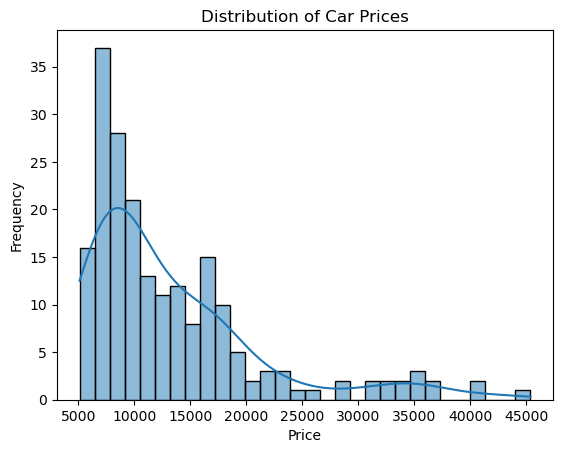

In [5]:
#Step 3.1: Visualize the Distribution of Car Prices
# Plot the distribution of car prices
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


C:\Users\alimd\AppData\Local\Temp\ipykernel_5440\3486818707.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


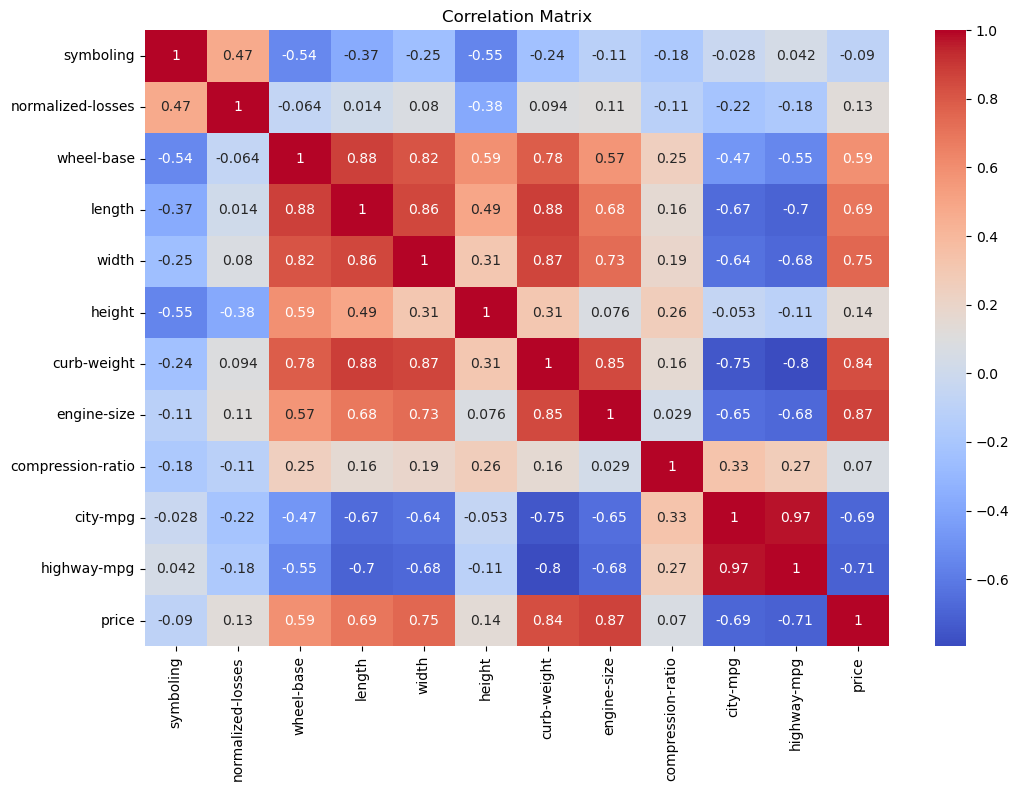

In [6]:
#Step 3.2: Correlation Analysis

# Create a correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# Task 4: Feature Engineering
Goal: Create new features from the existing ones.

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Convert the 'horsepower' column to numeric, setting errors='coerce' to replace non-numeric values with NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['curb-weight'] = pd.to_numeric(df['curb-weight'], errors='coerce')

# Now fill the NaN values with the mean of the respective column
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)
df['curb-weight'].fillna(df['curb-weight'].mean(), inplace=True)

# Create the 'horsepower_to_weight' feature
df['horsepower_to_weight'] = df['horsepower'] / df['curb-weight']

# List of numerical features to scale
numerical_features = ['horsepower', 'curb-weight', 'engine-size', 'horsepower_to_weight']

# Check if these features exist in the DataFrame
for feature in numerical_features:
    if feature not in df.columns:
        raise KeyError(f"The feature '{feature}' is not in the DataFrame")

# Initialize the scaler
scaler = StandardScaler()

# Scale the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Verify the scaling
print(df[numerical_features].head())


   horsepower  curb-weight  engine-size  horsepower_to_weight
0    0.203025    -0.019717     0.073864              0.412545
1    0.203025    -0.019717     0.073864              0.412545
2    1.359324     0.513275     0.605875              1.631820
3   -0.038991    -0.428668    -0.433965              0.421657
4    0.310587     0.515213     0.218958              0.097283


# Task 5: Training
Goal: Train a regression model using the relevant machine learning algorithm.

Step 5.1: Split the Data into Training and Testing Sets

In [11]:
# Define features (X) and target (y)
X = df[['horsepower', 'curb-weight', 'engine-size', 'horsepower_to_weight']]
y = df['price']

# Split into train and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


LinearRegression()

# Task 6: Model Evaluation
Goal: Evaluate the model's performance and summarize the findings.

Step 6.1: Make Predictions

In [13]:
# Predict car prices using the test data
y_pred = model.predict(X_test)


Step 6.2: Evaluate Model Performance
Calculate Mean Squared Error (MSE) and R-squared (R²).

In [14]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f'Mean Squared Error: {mse}')
print(f'R-squared Score: {r2}')


Mean Squared Error: 25473193.401188258
R-squared Score: 0.7783464207660367


Step 6.3: Visualize Actual vs. Predicted Prices

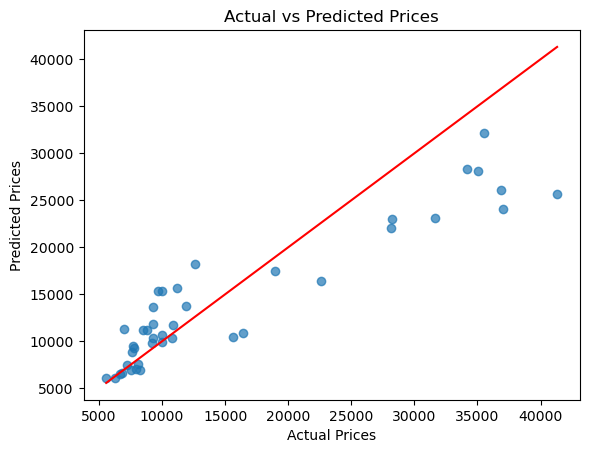

In [15]:
# Plot Actual vs Predicted Prices
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()
